In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv('/content/senasica_prod_aguacate_limpio.csv')

df_mich = df[df['Estado'] == 'Michoacán']
df_mich.head()

,Estado,Superficie_miles_Ha,Volumen_miles_Ton,Valor_millones_MXN,Anio
0,Michoacán,78.62738,820.22382,4505.384041,2001
3,Michoacán,81.89525,792.65890,3608.520637,2002
9,Michoacán,82.52300,800.45208,4869.582759,2003
16,Michoacán,86.54632,864.06947,5529.081638,2004
23,Michoacán,95.22282,895.09795,6963.748811,2005


In [3]:
# Calculamos la variable objetivo: Rendimiento (Toneladas / Hectáreas)
df_mich['Rendimiento'] = df_mich['Volumen_miles_Ton'] / df_mich['Superficie_miles_Ha']

# Definir variables (X = Año, y = Rendimiento)
X = df_mich[['Anio']].values
y_rendimiento = df_mich['Rendimiento'].values


/tmp/ipykernel_2574/4168416746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mich['Rendimiento'] = df_mich['Volumen_miles_Ton'] / df_mich['Superficie_miles_Ha']


--- Métricas del Árbol de Regresión ---
Rendimiento -> R2: 0.7604 | RMSE: 0.29 Ton/Ha


/tmp/ipykernel_2574/1362068470.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X) + 1, 0.1).reshape(-1, 1)


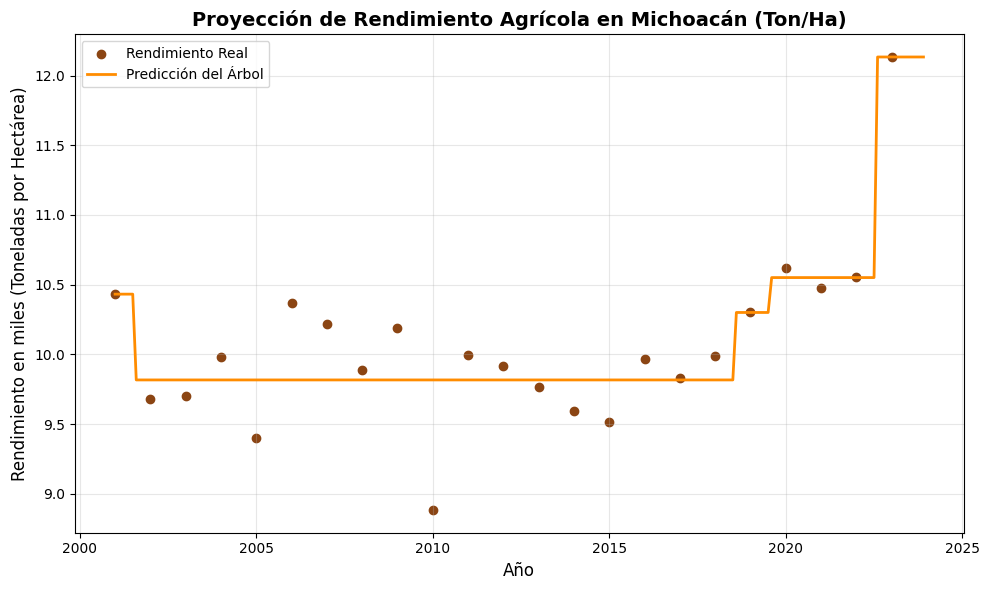

In [5]:

# Entrenamos el Árbol de Regresión
# Usamos max_depth=3 para encontrar los grandes umbrales históricos sin sobreajustar
arbol = DecisionTreeRegressor(max_depth=3, random_state=42)
arbol.fit(X, y_rendimiento)

# Generar Predicciones
y_pred_arbol = arbol.predict(X)

# Evaluar Métricas
r2_arbol = r2_score(y_rendimiento, y_pred_arbol)
rmse_arbol = np.sqrt(mean_squared_error(y_rendimiento, y_pred_arbol))

print("--- Métricas del Árbol de Regresión ---")
print(f"Rendimiento -> R2: {r2_arbol:.4f} | RMSE: {rmse_arbol:.2f} Ton/Ha")

# Visualización del Ajuste Escalonado
# Creamos un rango continuo de años para que se vea bien la "escalera" del árbol
X_grid = np.arange(min(X), max(X) + 1, 0.1).reshape(-1, 1)
y_grid_pred = arbol.predict(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(df_mich['Anio'], y_rendimiento, color='#8B4513', label='Rendimiento Real')
plt.plot(X_grid, y_grid_pred, color='#FF8C00', linewidth=2, label='Predicción del Árbol')

plt.title('Proyección de Rendimiento Agrícola en Michoacán (Ton/Ha)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Rendimiento en miles (Toneladas por Hectárea)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

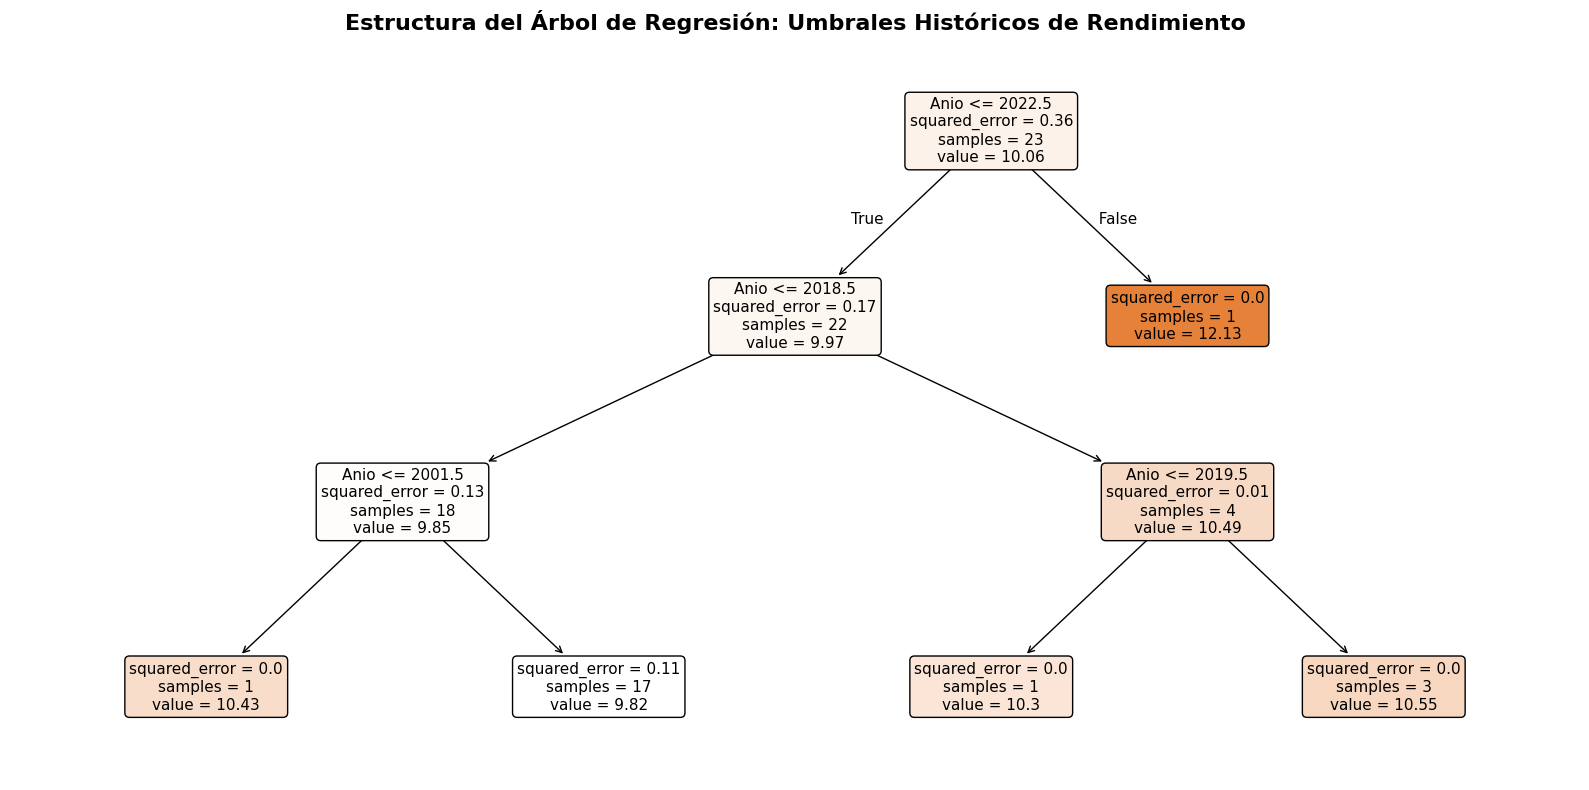

In [6]:
from sklearn.tree import plot_tree

# Configurar el tamaño de la figura para que los nodos se lean claramente
plt.figure(figsize=(16, 8))

# Generar el gráfico del árbol
plot_tree(arbol,
          feature_names=['Anio'],      # Nombre de nuestra variable predictora
          filled=True,                 # Colorea los nodos según el valor predicho
          rounded=True,                # Suaviza los bordes de las cajas
          fontsize=11,                 # Tamaño del texto
          precision=2)                 # Decimales a mostrar

plt.title('Estructura del Árbol de Regresión: Umbrales Históricos de Rendimiento', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()